# Prepare validation data set Narrabeen

In [1]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
path = path_to_data_folder+'03_Narrabeen_validation_data/'

## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import numpy as np
from shapely import Point, LineString

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_geometry, CD_visualisation

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
data_orig = pd.read_csv(path + 'Narrabeen_Profiles.csv')

In [5]:
# Add slopes between neighbouring profile points
mask = data_orig['Chainage'] != 0
# height diff
dh = data_orig['Elevation'].shift(1) - data_orig['Elevation']
# cross-shore distance diff
dx = data_orig['Chainage'] - data_orig['Chainage'].shift(1)
data_orig.loc[mask, 'slope'] = dh / dx

In [6]:
data_orig

,Site,Profile ID,Date,Chainage,Elevation,Flag,slope
0,NARRA,PF6,1976-04-27,0,6.29,EMERY,NaN
1,NARRA,PF6,1976-04-27,10,1.68,EMERY,0.461
2,NARRA,PF6,1976-04-27,20,0.10,EMERY,0.158
3,NARRA,PF6,1976-04-27,30,-0.95,EMERY,0.105
4,NARRA,PF4,1976-04-27,0,9.52,EMERY,NaN
...,...,...,...,...,...,...,...
158583,NARRA,PF4,2019-11-27,113,-0.82,GPS,0.070
158584,NARRA,PF4,2019-11-27,114,-0.82,GPS,0.000
158585,NARRA,PF4,2019-11-27,115,-0.85,GPS,0.030
158586,NARRA,PF4,2019-11-27,116,-0.91,GPS,0.060


## Convert polar to cartesian coordinates

In [7]:
def deg360_to_decimal(deg, minute, sec):
    '''
    Convert degrees given in deg, minute, seconds to decimal degrees.
    '''
    deci = np.abs(deg) + minute/60 + sec/3600
    if np.sign(deg) == -1:
        deci = -deci
    return deci

In [8]:
# Origin and orientation of each profile
# from data description paper table 3
lat_orig_pf1 = deg360_to_decimal(-33, 42, 20.65)
lon_orig_pf1 = deg360_to_decimal(151, 18, 16.30)
orientation_pf1 = 118.42 # degree North

lat_orig_pf2 = deg360_to_decimal(-33, 42, 33.45)
lon_orig_pf2 = deg360_to_decimal(151, 18, 10.33)
orientation_pf2 = 113.36

lat_orig_pf4 = deg360_to_decimal(-33, 43, 1.55)
lon_orig_pf4 = deg360_to_decimal(151, 17, 58.84)
orientation_pf4 = 100.26

lat_orig_pf6 = deg360_to_decimal(-33, 43, 29.81)
lon_orig_pf6 = deg360_to_decimal(151, 17, 58.65)
orientation_pf6 = 83.65

lat_orig_pf8 = deg360_to_decimal(-33, 43, 55.94)
lon_orig_pf8 = deg360_to_decimal(151, 18, 6.47)
orientation_pf8 = 60.48

In [9]:
# Initialise GeoDataFrame with the avaialable information
data_gdf = gpd.GeoDataFrame(columns=['profile', 'date', 'elev', 'slope', 'coords'], geometry='coords')
data_gdf.date = pd.to_datetime(data_orig['Date'])
data_gdf.elev = data_orig['Elevation']
data_gdf.slope = data_orig['slope']
data_gdf.profile = data_orig['Profile ID']
data_gdf = data_gdf.set_crs('4326')

In [10]:
# Get coordinates from start point, orientation and chainage
def get_profile_coordinates(data_gdf, profile, lat_orig, lon_orig, orientation):
    idx_pf, = np.where(data_gdf.profile == profile)
    chains = data_orig.loc[idx_pf,'Chainage']
    dists = CD_geometry.dist_meter_to_dist_deg(chains)

    lats, lons = CD_geometry.dist_angle_to_coords((lat_orig, lon_orig), dists, orientation/180*np.pi)

    data_gdf.loc[idx_pf, 'coords'] = gpd.points_from_xy(lons, lats)

get_profile_coordinates(data_gdf, 'PF1', lat_orig_pf1, lon_orig_pf1, orientation_pf1)
get_profile_coordinates(data_gdf, 'PF2', lat_orig_pf2, lon_orig_pf2, orientation_pf2)
get_profile_coordinates(data_gdf, 'PF4', lat_orig_pf4, lon_orig_pf4, orientation_pf4)
get_profile_coordinates(data_gdf, 'PF6', lat_orig_pf6, lon_orig_pf6, orientation_pf6)
get_profile_coordinates(data_gdf, 'PF8', lat_orig_pf8, lon_orig_pf8, orientation_pf8)

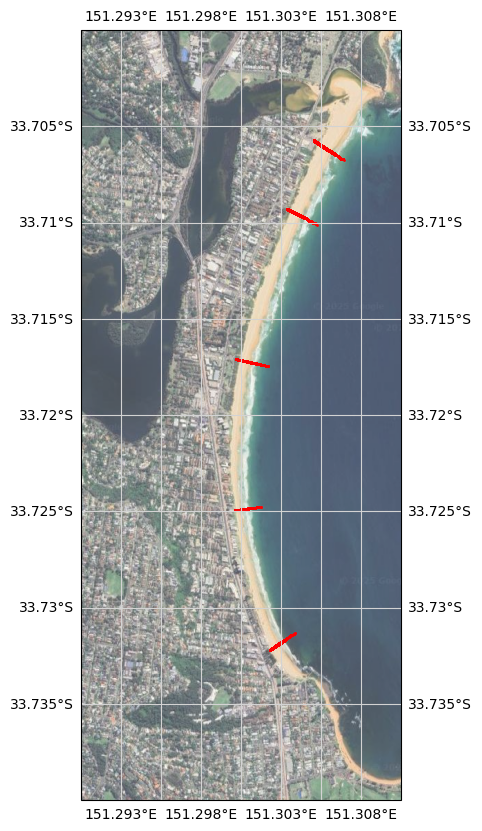

In [13]:
extent = [151.29, 151.31, -33.74, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)
ax.scatter(data_gdf.geometry.x, data_gdf.geometry.y, transform=ccrs.PlateCarree(), s=1, c='red')

In [14]:
data_gdf.to_file(path + 'narrabeen_profiles_with_coords.geojson')

## Distances between the profiles

In [14]:
def get_shapely_profile(profile):
    idx_pf, = np.where(data_gdf.profile == profile)
    pf = LineString(data_gdf.iloc[idx_pf].coords)
    pf = CD_geometry.transform_linestring(pf, '4326', '32356')
    return pf

In [15]:
pf1 = get_shapely_profile('PF1')
pf2 = get_shapely_profile('PF2')
pf4 = get_shapely_profile('PF4')
pf6 = get_shapely_profile('PF6')
pf8 = get_shapely_profile('PF8')

In [16]:
d12 = pf1.distance(pf2)
d24 = pf2.distance(pf4)
d46 = pf4.distance(pf6)
d68 = pf6.distance(pf8)

In [17]:
print(f'Minimum distance profile 1 - profile 2: {round(d12,1)} m')
print(f'Minimum distance profile 2 - profile 4: {round(d24,1)} m')
print(f'Minimum distance profile 4 - profile 6: {round(d46,1)} m')
print(f'Minimum distance profile 6 - profile 8: {round(d68,1)} m')

print(f'\nTotal study site along shore distance: {round(d12 + d24 + d46 + d68,1)} m')

Minimum distance profile 1 - profile 2: 400.5 m
Minimum distance profile 2 - profile 4: 863.3 m
Minimum distance profile 4 - profile 6: 811.1 m
Minimum distance profile 6 - profile 8: 752.9 m

Total study site along shore distance: 2827.8 m
